INFO:root:Starting FAR vs stat plot
2026-02-03T13:00:42.363+00:00 INFO : Starting FAR vs stat plot
2026-02-03T13:00:42.363+00:00 INFO : Starting FAR vs stat plot
2026-02-03T13:00:42.363+00:00 INFO : Starting FAR vs stat plot
2026-02-03T13:00:42.363+00:00 INFO : Starting FAR vs stat plot
2026-02-03T13:00:42.363+00:00 INFO : Starting FAR vs stat plot


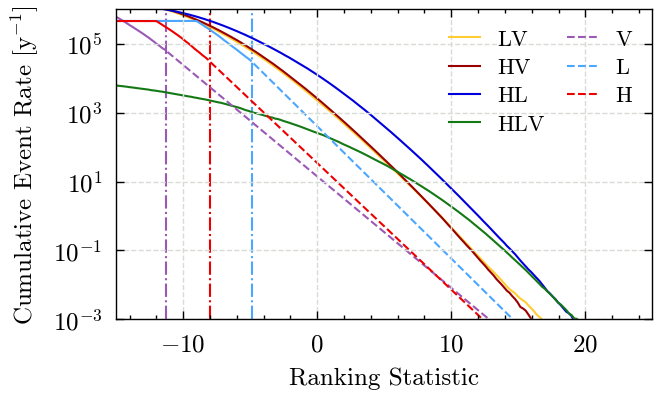

In [6]:
# FAR vs Ranking Statistic (exact reproduction of pycbc_page_fars_vs_stat)

import h5py
import numpy as np
import matplotlib.pyplot as plt
import logging

from pycbc import init_logging, results
from pycbc.events import significance
from pycbc.conversions import sec_to_year as convert_s_to_y

# -------------------------
# Parameters from CLI
# -------------------------

trigger_files = [
    "/home/saml.insley/o3/analysis/pycbc/a35_flow/output/full_data/L1V1-EXCLUDE_ZEROLAG_FULL_DATA_2DET-1265132995-614458.hdf",
    "/home/saml.insley/o3/analysis/pycbc/a35_flow/output/full_data/H1V1-EXCLUDE_ZEROLAG_FULL_DATA_2DET-1265132995-614458.hdf",
    "/home/saml.insley/o3/analysis/pycbc/a35_flow/output/full_data/H1L1-EXCLUDE_ZEROLAG_FULL_DATA_2DET-1265132995-614458.hdf",
    "/home/saml.insley/o3/analysis/pycbc/a35_flow/output/full_data/H1L1V1-EXCLUDE_ZEROLAG_FULL_DATA_3DET-1265132995-614458.hdf",
    "/home/saml.insley/o3/analysis/pycbc/a35_flow/output/full_data/V1-EXCLUDE_ZEROLAG_FULL_DATA_1DET-1265132995-614458.hdf",
    "/home/saml.insley/o3/analysis/pycbc/a35_flow/output/full_data/L1-EXCLUDE_ZEROLAG_FULL_DATA_1DET-1265132995-614458.hdf",
    "/home/saml.insley/o3/analysis/pycbc/a35_flow/output/full_data/H1-EXCLUDE_ZEROLAG_FULL_DATA_1DET-1265132995-614458.hdf",
]

ifo_combos = ["H1", "L1", "V1", "H1L1", "H1V1", "L1V1", "H1L1V1"]

output_file = "../Plots/Background.png"

min_x = -15.0
max_x = 25.0
verbose = 1

# -------------------------
# FAR / fit configuration (from CLI)
# -------------------------

sig_dict = {
    "H1":   dict(method="trigger_fit", fit_function="exponential", fit_threshold=-8.0,  limit_ifar=1000),
    "L1":   dict(method="trigger_fit", fit_function="exponential", fit_threshold=-4.9,  limit_ifar=1000),
    "V1":   dict(method="trigger_fit", fit_function="exponential", fit_threshold=-11.3, limit_ifar=1000),
    "H1L1": dict(method="n_louder"),
    "H1V1": dict(method="n_louder"),
    "L1V1": dict(method="n_louder"),
    "H1L1V1": dict(method="n_louder"),
}

# -------------------------
# Logging
# -------------------------

init_logging(verbose)
logging.info("Starting FAR vs stat plot")

# -------------------------
# Plot style maps
# -------------------------

coinc_color_map = {
    'H':  '#ee0000',
    'L':  '#4ba6ff',
    'V':  '#9b59b6',
    'HL': '#0000DD',
    'LV': '#FFCC33',
    'HV': '#990000',
    'HLV': np.array([20, 120, 20]) / 255.
}

coinc_line_map = {
    'H':  '--',
    'L':  '--',
    'V':  '--',
    'HL': '-',
    'LV': '-',
    'HV': '-',
    'HLV':'-'
}

# -------------------------
# Figure
# -------------------------

fig = plt.figure()
ax = fig.add_subplot(111)

ifar_calc_points = np.linspace(min_x, max_x, 200)
fitted_combos = []

# -------------------------
# Loop over trigger files
# -------------------------

for fname in trigger_files:

    with h5py.File(fname, "r") as f:
        sig_key = f.attrs["ifos"].replace(" ", "")     # e.g. H1L1
        coinc_key = sig_key.replace("1", "")           # e.g. HL

        stat_exc = f["background_exc"]["stat"][:]
        dec_fac_exc = f["background_exc"]["decimation_factor"][:]
        ifar_exc = f["background_exc"]["ifar"][:]
        bg_time = convert_s_to_y(f.attrs["background_time_exc"])


    cfg = sig_dict[sig_key]

    # -------------------------
    # Trigger-fit case
    # -------------------------

    if cfg.get("method") == "trigger_fit":
        fitted_combos.append(sig_key)

        far_tuple = significance.get_far(
            stat_exc,
            ifar_calc_points,
            dec_fac_exc,
            bg_time,
            method="trigger_fit",
            fit_function=cfg["fit_function"],
            fit_threshold=cfg["fit_threshold"],
            limit_ifar=cfg["limit_ifar"],
        )

        far = far_tuple[1]
        ft = cfg["fit_threshold"]

        ax.plot(
            ifar_calc_points[ifar_calc_points < ft],
            far[ifar_calc_points < ft],
            "-",
            c=coinc_color_map[coinc_key],
            zorder=-5,
        )

        ax.plot(
            ifar_calc_points[ifar_calc_points > ft],
            far[ifar_calc_points > ft],
            coinc_line_map[coinc_key],
            c=coinc_color_map[coinc_key],
            label=coinc_key,
            zorder=-5,
        )

    # -------------------------
    # n-louder case
    # -------------------------

    else:
        far_tuple = significance.get_far(
            stat_exc,
            ifar_calc_points,
            dec_fac_exc,
            bg_time,
            method="n_louder",
        )

        ax.plot(
            ifar_calc_points,
            far_tuple[1],
            "-",
            c=coinc_color_map[coinc_key],
            label=coinc_key,
            zorder=-5,
        )

# -------------------------
# Plot fit thresholds
# -------------------------

for combo in fitted_combos:
    ck = combo.replace("1", "")
    ax.axvline(
        sig_dict[combo]["fit_threshold"],
        ls="-.",
        c=coinc_color_map[ck],
        zorder=-10,
    )

# -------------------------
# Axes / labels
# -------------------------

ax.semilogy()
ax.set_xlim(min_x, max_x)
ax.set_ylim(1e-3, 1e6)
ax.grid()
ax.legend(ncol=2)

ax.set_xlabel("Ranking Statistic")
ax.set_ylabel(r"Cumulative Event Rate [y$^{-1}$]")
ax.tick_params(axis="both")

# -------------------------
# Save + show
# -------------------------


plt.savefig("../Plots/Backgrounds.png")
plt.show()